In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('cosmetics.csv')
print(df.head())
print(df.info())
print(df.describe())

# Unique feature check
print('\nUnique feature:')
print(df.nunique())

# Check missing value, duplicate, and garbage data
print('\nany missing value?')
print(df.isnull().sum())

print('\nany duplicate?')
print(df.duplicated().sum())

for col in df.columns:
    weird_types = df[col].apply(type).unique()
    if len(weird_types) > 1:
        print(f" '{col}' feature has mixed type data: {weird_types}")
    else:
        print(f" '{col}' save (just type {weird_types[0].__name__})")



         Label           Brand                                           Name  \
0  Moisturizer          LA MER                                Crème de la Mer   
1  Moisturizer           SK-II                       Facial Treatment Essence   
2  Moisturizer  DRUNK ELEPHANT                     Protini™ Polypeptide Cream   
3  Moisturizer          LA MER                    The Moisturizing Soft Cream   
4  Moisturizer    IT COSMETICS  Your Skin But Better™ CC+™ Cream with SPF 50+   

   Price  Rank                                        Ingredients  \
0    175   4.1  Algae (Seaweed) Extract, Mineral Oil, Petrolat...   
1    179   4.1  Galactomyces Ferment Filtrate (Pitera), Butyle...   
2     68   4.4  Water, Dicaprylyl Carbonate, Glycerin, Ceteary...   
3    175   3.8  Algae (Seaweed) Extract, Cyclopentasiloxane, P...   
4     38   4.1  Water, Snail Secretion Filtrate, Phenyl Trimet...   

   Combination  Dry  Normal  Oily  Sensitive  
0            1    1       1     1          1  
1   

feature Name is unique, without missing value, without duplicated, and data garbage. has low variance in each features except price.

In [36]:
'''
Because there is no sales feature let's make it from feature rank. Customer can't give a rank if they not buy the product, simple logic. So, we can use that feature.
'''

import warnings
warnings.filterwarnings('ignore')
# Feature engineering
# We don't need the value, so replace it with 1 
df['Rank_1'] = (df['Rank'] * 0) + 1
print('the value must be 1:')
print(df['Rank_1'].head())

# Make sales feature
df['Sales'] = df['Rank_1'] * df['Price']
print(df[['Sales', 'Name']].head())

# Checking sales by label
print('\nSales by label:\n', df.groupby('Label')['Sales'].agg(['count','sum','max','mean',]).sort_values(by='sum',ascending=False))

# Sales by skin type
df_melted = df.melt(id_vars=['Sales'], value_vars=['Combination', 'Dry', 'Normal', 'Oily','Sensitive'], var_name='Skin', value_name='Skin_val')

# Filter for rows where the skin value applies (assuming 1 or True)
df_active = df_melted[df_melted['Skin_val'] == 1]

# Best product by rating
best_product = df.groupby('Rank')[['Label', 'Brand', 'Name','Ingredients']].agg('max').sort_index(ascending=False).head(7)
print(best_product)



the value must be 1:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Rank_1, dtype: float64
   Sales                                           Name
0  175.0                                Crème de la Mer
1  179.0                       Facial Treatment Essence
2   68.0                     Protini™ Polypeptide Cream
3  175.0                    The Moisturizing Soft Cream
4   38.0  Your Skin But Better™ CC+™ Cream with SPF 50+

Sales by label:
              count      sum    max       mean
Label                                        
Moisturizer    298  20588.0  325.0  69.087248
Treatment      248  19636.0  370.0  79.177419
Eye cream      209  13293.0  260.0  63.602871
Face Mask      266  11338.0  250.0  42.624060
Cleanser       281   9161.0   95.0  32.601423
Sun protect    170   7804.0  260.0  45.905882
          Label                Brand  \
Rank                                   
5.0   Treatment           SUPERGOOP!   
4.9   Treatment             SHISEIDO   
4.8   Treatment  YOUTH 

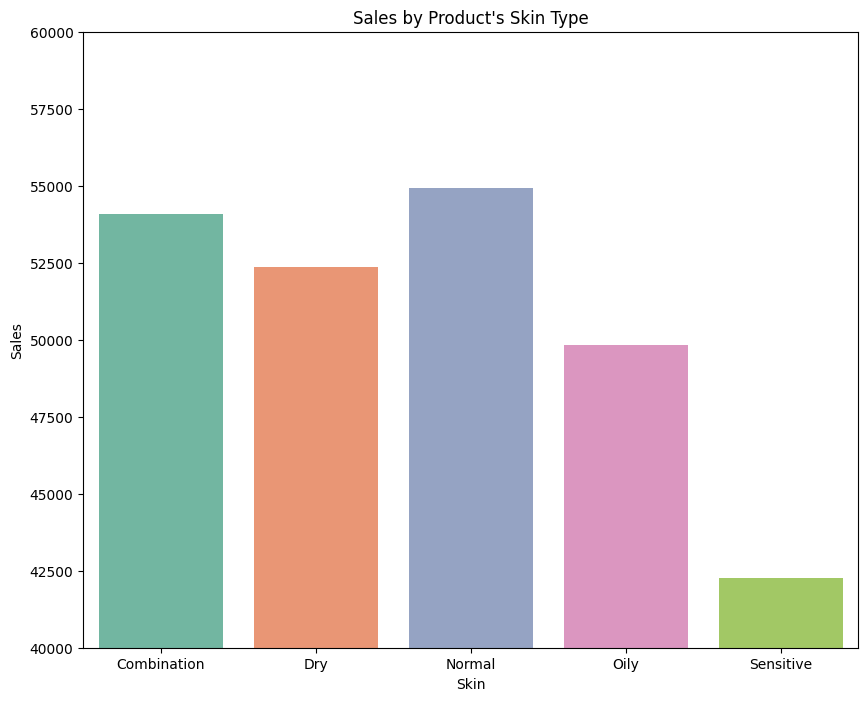

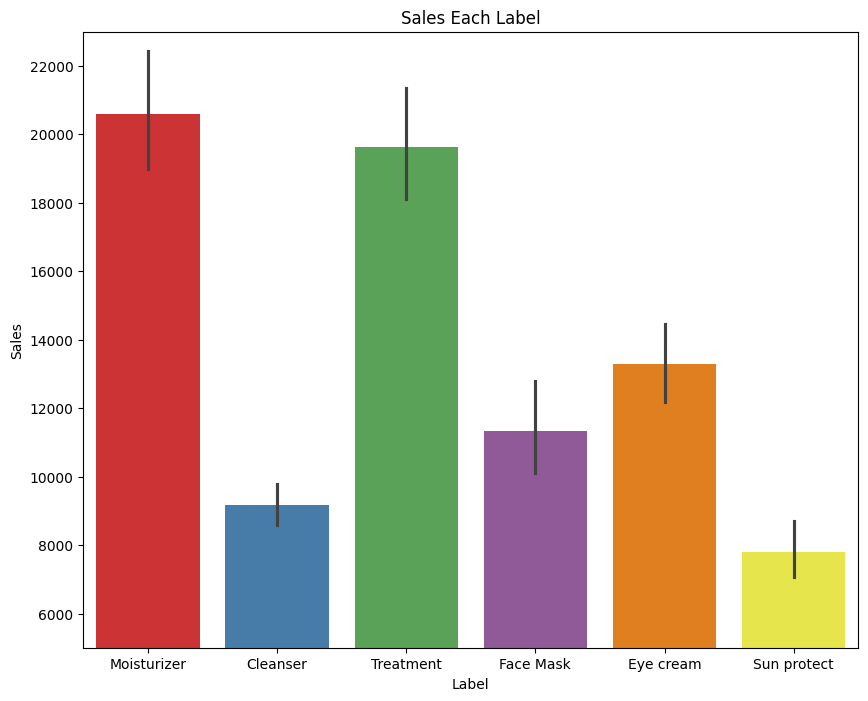

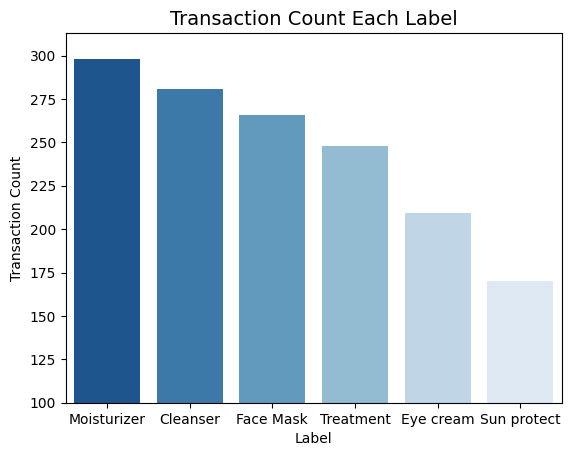

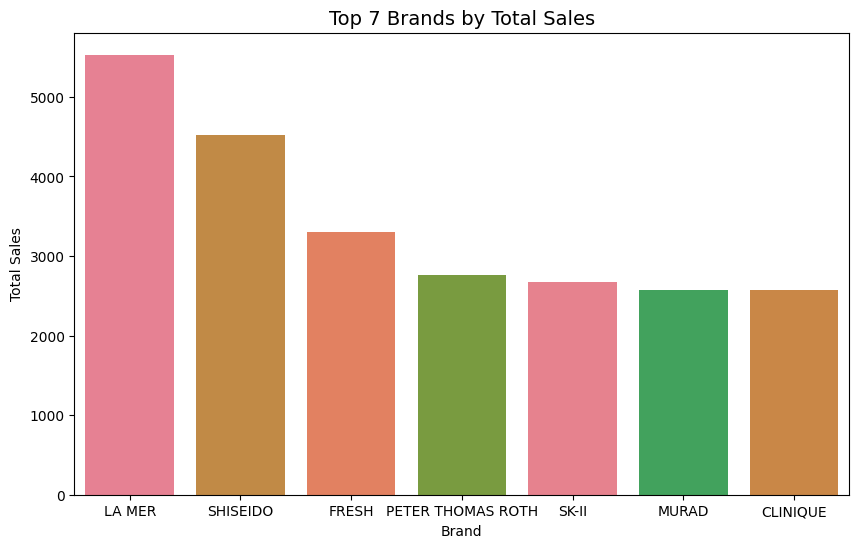

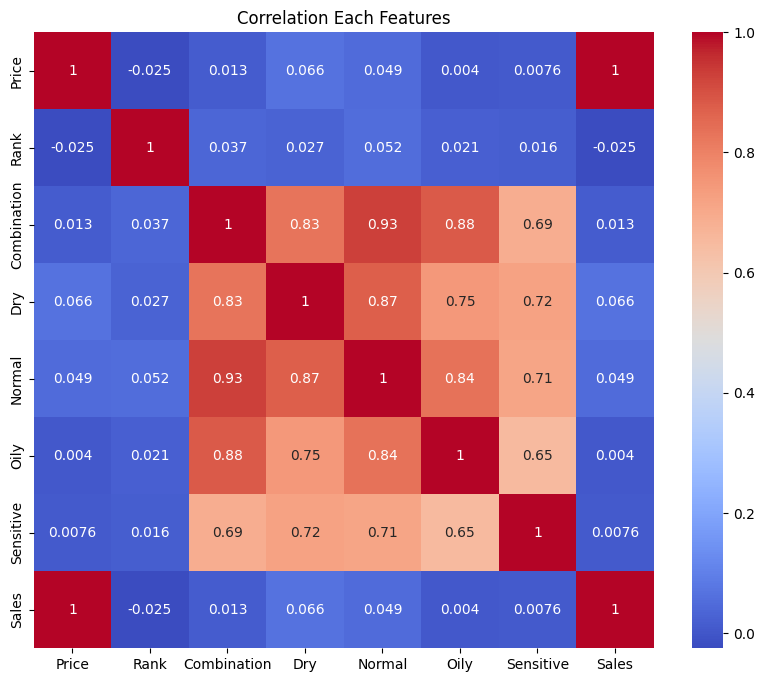

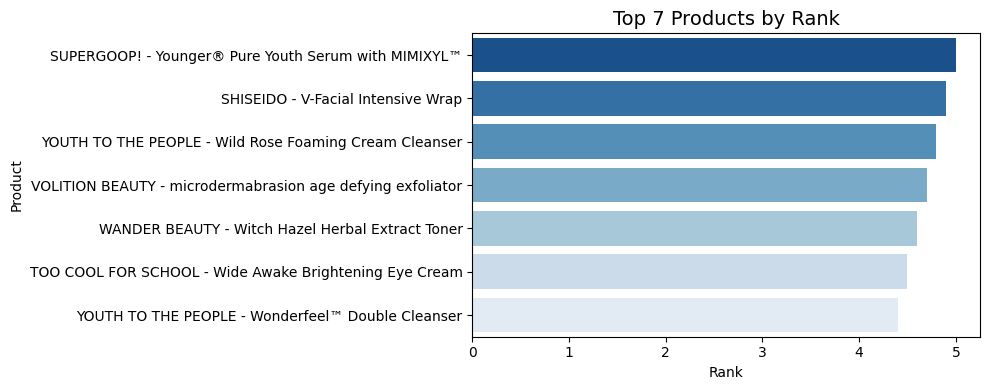

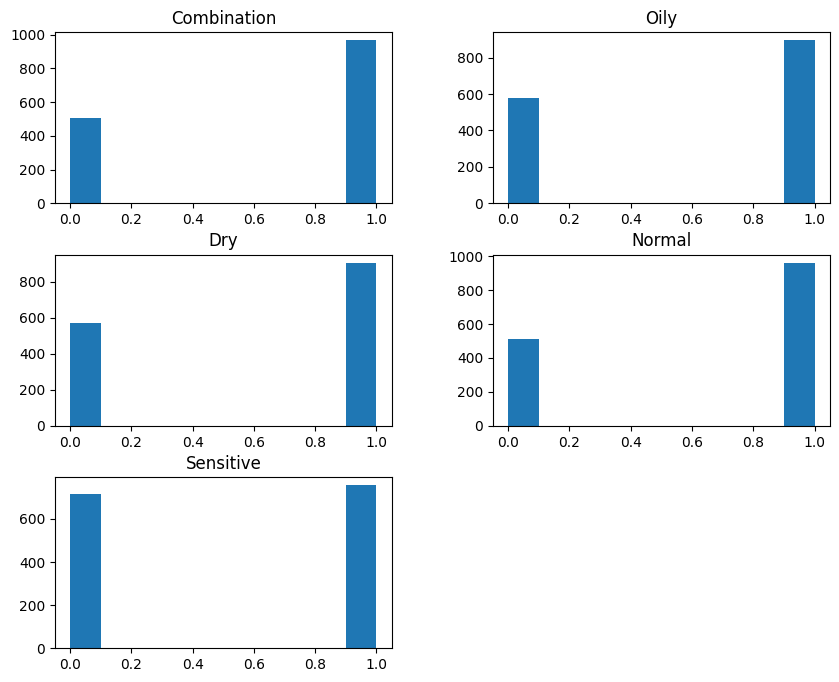

In [35]:
# Visualize
# Sales by product's skin type
plt.figure(figsize=(10, 8))
sns.barplot(data=df_active, x='Skin', y='Sales', palette='Set2', estimator=sum, errorbar=None)
plt.ylim(40000, 60000)
plt.title("Sales by Product's Skin Type")
plt.show()

# Sales by label
plt.figure(figsize=(10,8))
sns.barplot(data=df, x='Label', y='Sales', palette='Set1', estimator='sum')
plt.ylim(5000, 23000)
plt.title('Sales Each Label')
plt.show()

# Transaction count by label
sns.countplot(data=df, x='Label', order=df['Label'].value_counts().index, palette='Blues_r')
plt.ylim(100,)
plt.title('Transaction Count Each Label', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Transaction Count')
plt.show()

# Total Sales per brand (top 7)
top_7_sales_brands = df.groupby('Brand')['Sales'].sum().nlargest(7).index

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Brand', y='Sales', order=top_7_sales_brands, estimator='sum', errorbar=None, hue='Brand', legend=False,)
plt.title('Top 7 Brands by Total Sales', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Total Sales')
plt.show()

# Correlation each feature
plt.figure(figsize=(10,8))
df_corr = df.drop(columns='Rank_1')
sns.heatmap(df_corr.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Each Features')
plt.show()

# Top 7 products by rank
best_product['Product_Label'] = best_product['Brand'] + " - " + best_product['Name']

plt.figure(figsize=(10, 4))
sns.barplot(x=best_product.index, y=best_product['Product_Label'], palette="Blues_r")
plt.title("Top 7 Products by Rank", fontsize=14)
plt.xlabel("Rank")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

value_skin = df[['Combination', 'Oily', 'Dry', 'Normal', 'Sensitive']]
value_skin.hist(bins=10, figsize=(10,8), grid=False)
plt.title('Distribution of skin type')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import hamming_loss, f1_score, classification_report

# Split data
x = df['Ingredients']
y = df[['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Modelling
models = {
    'Logistic Regression': MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    'Linear SVC': MultiOutputClassifier(LinearSVC()),
    'SGD Classifier': MultiOutputClassifier(SGDClassifier()),
    'Passive Aggressive': MultiOutputClassifier(PassiveAggressiveClassifier()),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Multinomial NB': MultiOutputClassifier(MultinomialNB()),
}

results = {}

# Pipeline
for name, method in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=2500)),
        ('models', method),
    ])

    pipeline.fit(x_train, y_train)

    predict = pipeline.predict(x_test)

    results[name] = {
        'hamming_loss': hamming_loss(y_test, predict),
        'f1_micro': f1_score(y_test, predict, average='micro'),
        'f1_macro': f1_score(y_test, predict, average='macro'),
    }
    print(f'\n{name}:')
    print(classification_report(y_test, predict, target_names=y.columns))

results_df = pd.DataFrame(results).T
print('\n', results_df.round(3))


Logistic Regression:
              precision    recall  f1-score   support

 Combination       0.71      0.94      0.80       189
         Dry       0.66      0.91      0.77       173
      Normal       0.72      0.93      0.81       190
        Oily       0.67      0.90      0.77       174
   Sensitive       0.68      0.71      0.69       150

   micro avg       0.69      0.88      0.77       876
   macro avg       0.69      0.88      0.77       876
weighted avg       0.69      0.88      0.77       876
 samples avg       0.58      0.60      0.58       876


Linear SVC:
              precision    recall  f1-score   support

 Combination       0.74      0.86      0.79       189
         Dry       0.69      0.84      0.76       173
      Normal       0.74      0.88      0.80       190
        Oily       0.69      0.79      0.74       174
   Sensitive       0.65      0.71      0.68       150

   micro avg       0.71      0.82      0.76       876
   macro avg       0.70      0.82      0.7